## Загрузка данных

In [1]:
import pandas as pd

df = pd.read_csv('../data/rzd_data.csv')
df.head()

,number,name,city,route,departure_time,arrival_time,from_station,to_station,rating,time_in_road,date,wagon_type,wagon_seats,wagon_price
0,№ 022А,Ночной Экспресс,Санкт-Петербург,Москва → Санкт-Петербург,00:25,08:53,Ленинградский вокзал,Московский вокзал,9.8,08 ч 28 м,01.06.2026,Купе,Мест: 285,"5 828,6 R"
1,№ 022А,Ночной Экспресс,Санкт-Петербург,Москва → Санкт-Петербург,00:25,08:53,Ленинградский вокзал,Московский вокзал,9.8,08 ч 28 м,01.06.2026,СВ,Мест: 15,"15 980,2 R"
2,№ 016А,Арктика,Санкт-Петербург,Москва → Санкт-Петербург → Мурманск,00:46,09:15,Ленинградский вокзал,Ладожский вокзал,8.1,08 ч 29 м,01.06.2026,Плацкарт,Мест: 32,"3 577,8 R"
3,№ 016А,Арктика,Санкт-Петербург,Москва → Санкт-Петербург → Мурманск,00:46,09:15,Ленинградский вокзал,Ладожский вокзал,8.1,08 ч 29 м,01.06.2026,Купе,Мест: 35,"5 761,7 R"
4,№ 016А,Арктика,Санкт-Петербург,Москва → Санкт-Петербург → Мурманск,00:46,09:15,Ленинградский вокзал,Ладожский вокзал,8.1,08 ч 29 м,01.06.2026,СВ,Мест: 12,"16 153,5 R"


In [2]:
print(f"Количество строк: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")

Количество строк: 20412
Количество столбцов: 14


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20412 entries, 0 to 20411
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number          20412 non-null  str    
 1   name            11052 non-null  str    
 2   city            20412 non-null  str    
 3   route           20412 non-null  str    
 4   departure_time  20412 non-null  str    
 5   arrival_time    20412 non-null  str    
 6   from_station    20412 non-null  str    
 7   to_station      19254 non-null  str    
 8   rating          19575 non-null  float64
 9   time_in_road    20412 non-null  str    
 10  date            20412 non-null  str    
 11  wagon_type      20412 non-null  str    
 12  wagon_seats     20412 non-null  str    
 13  wagon_price     20412 non-null  str    
dtypes: float64(1), str(13)
memory usage: 2.2 MB


In [4]:
nulls = df.isna().sum()
nulls[nulls > 0]

name          9360
to_station    1158
rating         837
dtype: int64

Причина пропусков:

 - name: полr определено только для фирменных поездов, остальные имеют только номер

 - rating: некоторые вагоны не имеют отзывов

 - to_station: некоторые станции не имеют названия, только название населенного пункта

## Feature engineering

In [5]:
df['name'].nunique()

48

In [6]:
df.loc[df['name'].isna(), 'name'] = 'Номерной'

In [7]:
df.loc[df['to_station'].isna(), 'to_station'] = df.loc[df['to_station'].isna(), 'city']

Строками в данных являются вагоны, что не оч удобно для анализа, сгруппируем записи по поездам

In [8]:
df.columns

Index(['number', 'name', 'city', 'route', 'departure_time', 'arrival_time',
       'from_station', 'to_station', 'rating', 'time_in_road', 'date',
       'wagon_type', 'wagon_seats', 'wagon_price'],
      dtype='str')

Сделаем названия столбцов более информативными

In [9]:
df = df.rename(columns={'name': 'train_name', 'number': 'train_id'})

In [10]:
df['n_stations'] = df['route'].str.count('→')

In [11]:
df['n_stations'].value_counts()

n_stations
2    12393
1     5931
3     2088
Name: count, dtype: int64

Больше трех промежуточных пунктов не бывает

In [12]:
df['wagon_price'] = df['wagon_price'].str.rstrip(" R").replace(" ", "", regex=True).replace(",", ".", regex=True).astype(float)

In [13]:
df.head()

,train_id,train_name,city,route,departure_time,arrival_time,from_station,to_station,rating,time_in_road,date,wagon_type,wagon_seats,wagon_price,n_stations
0,№ 022А,Ночной Экспресс,Санкт-Петербург,Москва → Санкт-Петербург,00:25,08:53,Ленинградский вокзал,Московский вокзал,9.8,08 ч 28 м,01.06.2026,Купе,Мест: 285,5828.6,1
1,№ 022А,Ночной Экспресс,Санкт-Петербург,Москва → Санкт-Петербург,00:25,08:53,Ленинградский вокзал,Московский вокзал,9.8,08 ч 28 м,01.06.2026,СВ,Мест: 15,15980.2,1
2,№ 016А,Арктика,Санкт-Петербург,Москва → Санкт-Петербург → Мурманск,00:46,09:15,Ленинградский вокзал,Ладожский вокзал,8.1,08 ч 29 м,01.06.2026,Плацкарт,Мест: 32,3577.8,2
3,№ 016А,Арктика,Санкт-Петербург,Москва → Санкт-Петербург → Мурманск,00:46,09:15,Ленинградский вокзал,Ладожский вокзал,8.1,08 ч 29 м,01.06.2026,Купе,Мест: 35,5761.7,2
4,№ 016А,Арктика,Санкт-Петербург,Москва → Санкт-Петербург → Мурманск,00:46,09:15,Ленинградский вокзал,Ладожский вокзал,8.1,08 ч 29 м,01.06.2026,СВ,Мест: 12,16153.5,2


In [14]:
def validation(row):
    return row['city'] in row['route']

validation_mask = df.apply(validation, axis=1)
df = df[validation_mask]

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24],
 [Text(0, 0, 'Барнаул'),
  Text(1, 0, 'Махачкала'),
  Text(2, 0, 'Хабаровск'),
  Text(3, 0, 'Владивосток'),
  Text(4, 0, 'Ижевск'),
  Text(5, 0, 'Уфа'),
  Text(6, 0, 'Ульяновск'),
  Text(7, 0, 'Волгоград'),
  Text(8, 0, 'Пермь'),
  Text(9, 0, 'Челябинск'),
  Text(10, 0, 'Иркутск'),
  Text(11, 0, 'Красноярск'),
  Text(12, 0, 'Саратов'),
  Text(13, 0, 'Новосибирск'),
  Text(14, 0, 'Самара'),
  Text(15, 0, 'Омск'),
  Text(16, 0, 'Казань'),
  Text(17, 0, 'Тюмень'),
  Text(18, 0, 'Екатеринбург'),
  Text(19, 0, 'Краснодар'),
  Text(20, 0, 'Ярославль'),
  Text(21, 0, 'Нижний Новгород'),
  Text(22, 0, 'Ростов-на-Дону'),
  Text(23, 0, 'Воронеж'),
  Text(24, 0, 'Санкт-Петербург')])

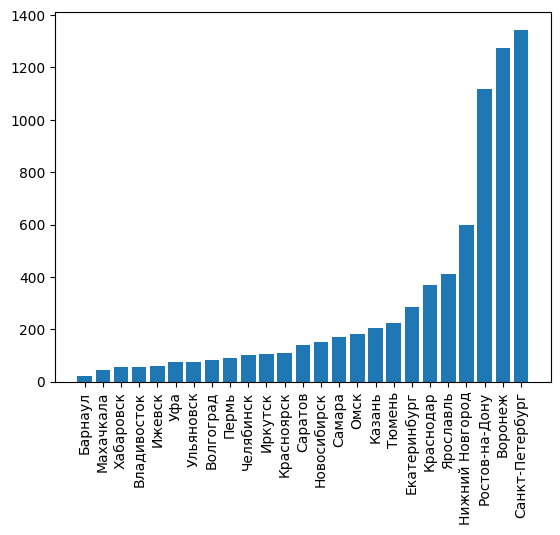

In [15]:
import matplotlib.pyplot as plt

stations_df = df.drop_duplicates(subset=["train_id", "train_name", "city", "route", "departure_time", "arrival_time", "from_station", "to_station", "rating", "time_in_road", "date"])
rez = stations_df.groupby('city').size().reset_index(name='count').sort_values('count')
plt.bar(rez['city'], rez['count'])
plt.xticks(rotation=90)


In [16]:
stations_dist = df.groupby(['train_id', 'city']).size().reset_index()
stations_dist

,train_id,city,0
0,№ 001И,Волгоград,84
1,№ 002А,Санкт-Петербург,89
2,№ 002Й,Казань,71
3,№ 002Э,Владивосток,54
4,№ 002Э,Екатеринбург,60
...,...,...,...
326,№ 778А,Санкт-Петербург,216
327,№ 780А,Санкт-Петербург,216
328,№ 782А,Санкт-Петербург,198
329,№ 784А,Санкт-Петербург,229


(array([ 0.,  2.,  4.,  6.,  8., 10., 12.]),
 [Text(0.0, 0, '0'),
  Text(2.0, 0, '2'),
  Text(4.0, 0, '4'),
  Text(6.0, 0, '6'),
  Text(8.0, 0, '8'),
  Text(10.0, 0, '10'),
  Text(12.0, 0, '12')])

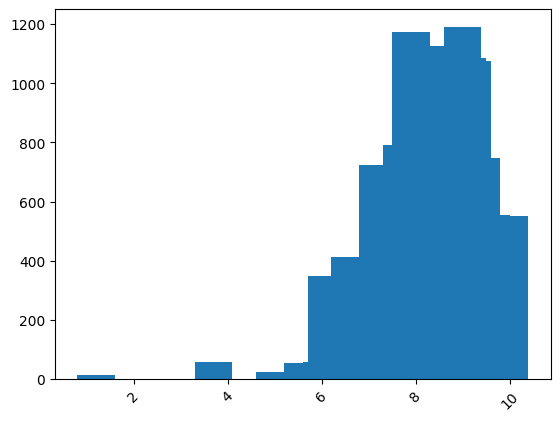

In [17]:
stations_dist = df['rating'].value_counts()

import matplotlib.pyplot as plt

plt.figure()
plt.bar(stations_dist.index, stations_dist.values)
plt.xticks(rotation=45)

([<matplotlib.patches.Wedge at 0x116bf7770>,
 [Text(0.500574766460479, 0.9795023752819781, 'Купе'),
  Text(-1.0963748098232362, 0.08923158849344169, 'Плацкарт'),
  Text(-0.37242035672710777, -1.0350377181027048, 'СВ'),
  Text(0.2298984211495434, -1.0757075420173214, 'Сидячий'),
  Text(0.45651046058094724, -1.0007987806648104, 'Базовый класс'),
  Text(0.6504275043864395, -0.8870986763250346, 'Бизнес класс'),
  Text(0.7998960904351003, -0.755093533614639, 'Эконом класс'),
  Text(1.037873647437814, -0.3644424398367021, 'Другой')])

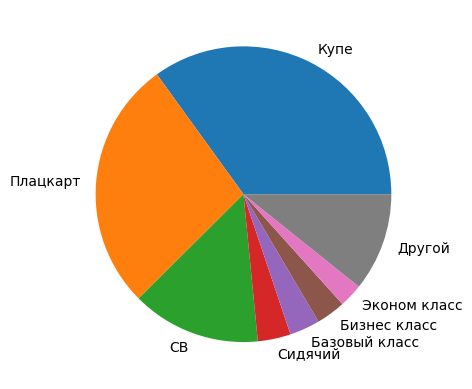

In [18]:
wagon_types_dist = df['wagon_type'].value_counts()
top_dist = wagon_types_dist[:7]
top_dist['Другой'] = wagon_types_dist[7:].sum()
plt.figure()
plt.pie(top_dist, labels=top_dist.index)

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x116bf67b0>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x116bf7620>,
 'cmins': <matplotlib.collections.LineCollection at 0x116eeb390>,
 'cbars': <matplotlib.collections.LineCollection at 0x116eeb4d0>,
 'cmedians': <matplotlib.collections.LineCollection at 0x116eeb610>}

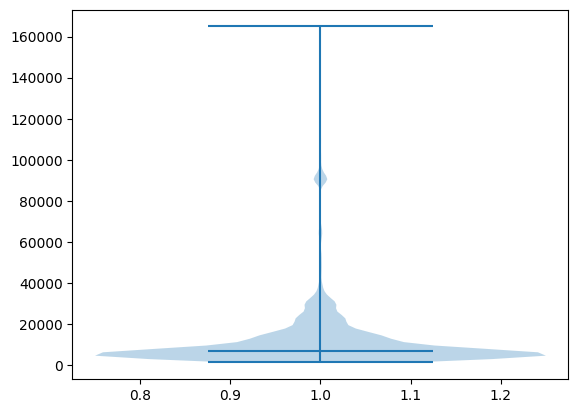

In [19]:
plt.figure()
plt.violinplot(df['wagon_price'], showmedians=True)

In [20]:
df['wagon_price'].median()

np.float64(6774.6)

In [21]:
def convert_time(time):
    days = "0"
    hours = "0"
    mins = "0"
    if 'дн' in time:
        days, time = time.split('дн')
    if 'ч' in time:
        hours, time = time.split('ч')
    if 'м' in time:
        mins, time = time.split('м')
    return int(mins.strip()) + int(hours.strip()) * 60 + int(days.strip()) * 60 * 24


df['minutes_in_road'] = df['time_in_road'].apply(convert_time)
df['wagon_seats'] = df['wagon_seats'].str.replace("Мест: ", "", regex=True).apply(int)
df = df.drop(columns=['time_in_road'])

In [22]:
df.head()

,train_id,train_name,city,route,departure_time,arrival_time,from_station,to_station,rating,date,wagon_type,wagon_seats,wagon_price,n_stations,minutes_in_road
0,№ 022А,Ночной Экспресс,Санкт-Петербург,Москва → Санкт-Петербург,00:25,08:53,Ленинградский вокзал,Московский вокзал,9.8,01.06.2026,Купе,285,5828.6,1,508
1,№ 022А,Ночной Экспресс,Санкт-Петербург,Москва → Санкт-Петербург,00:25,08:53,Ленинградский вокзал,Московский вокзал,9.8,01.06.2026,СВ,15,15980.2,1,508
2,№ 016А,Арктика,Санкт-Петербург,Москва → Санкт-Петербург → Мурманск,00:46,09:15,Ленинградский вокзал,Ладожский вокзал,8.1,01.06.2026,Плацкарт,32,3577.8,2,509
3,№ 016А,Арктика,Санкт-Петербург,Москва → Санкт-Петербург → Мурманск,00:46,09:15,Ленинградский вокзал,Ладожский вокзал,8.1,01.06.2026,Купе,35,5761.7,2,509
4,№ 016А,Арктика,Санкт-Петербург,Москва → Санкт-Петербург → Мурманск,00:46,09:15,Ленинградский вокзал,Ладожский вокзал,8.1,01.06.2026,СВ,12,16153.5,2,509


In [23]:
df.to_csv('../data/processed_rzd.csv', index=False)

In [24]:
df['weekend_departure'] = (pd.to_datetime(df['date'], format='%d.%m.%Y').dt.weekday > 4).astype(bool)

In [25]:
budni_df = df[~df['weekend_departure'] & df['wagon_type'].isin(['Купе', 'Плацкарт'])]
weekend_df = df[df['weekend_departure'] & df['wagon_type'].isin(['Купе', 'Плацкарт'])]

NameError: name 'sns' is not defined

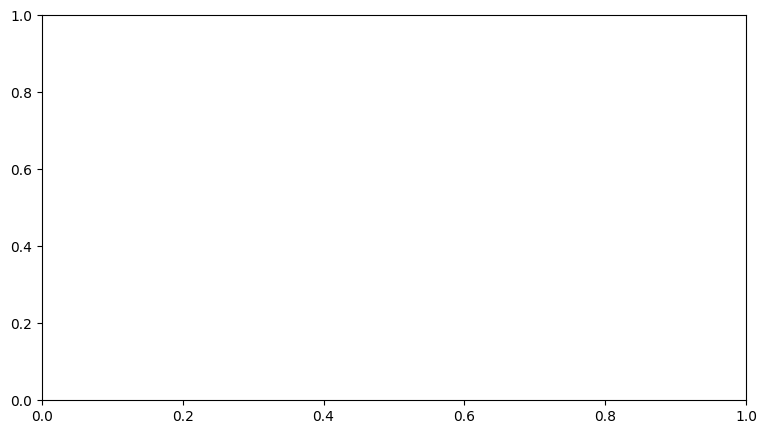

In [26]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
sns.violinplot(data=budni_df, x='wagon_type', y='wagon_price')
plt.title('Будни')

plt.subplot(1, 2, 2)
sns.violinplot(data=weekend_df, x='wagon_type', y='wagon_price')
plt.title('Выходные')